--- Generating Behavioral Validation Charts with Footer Legends ---


Plotting PERDULARIO...


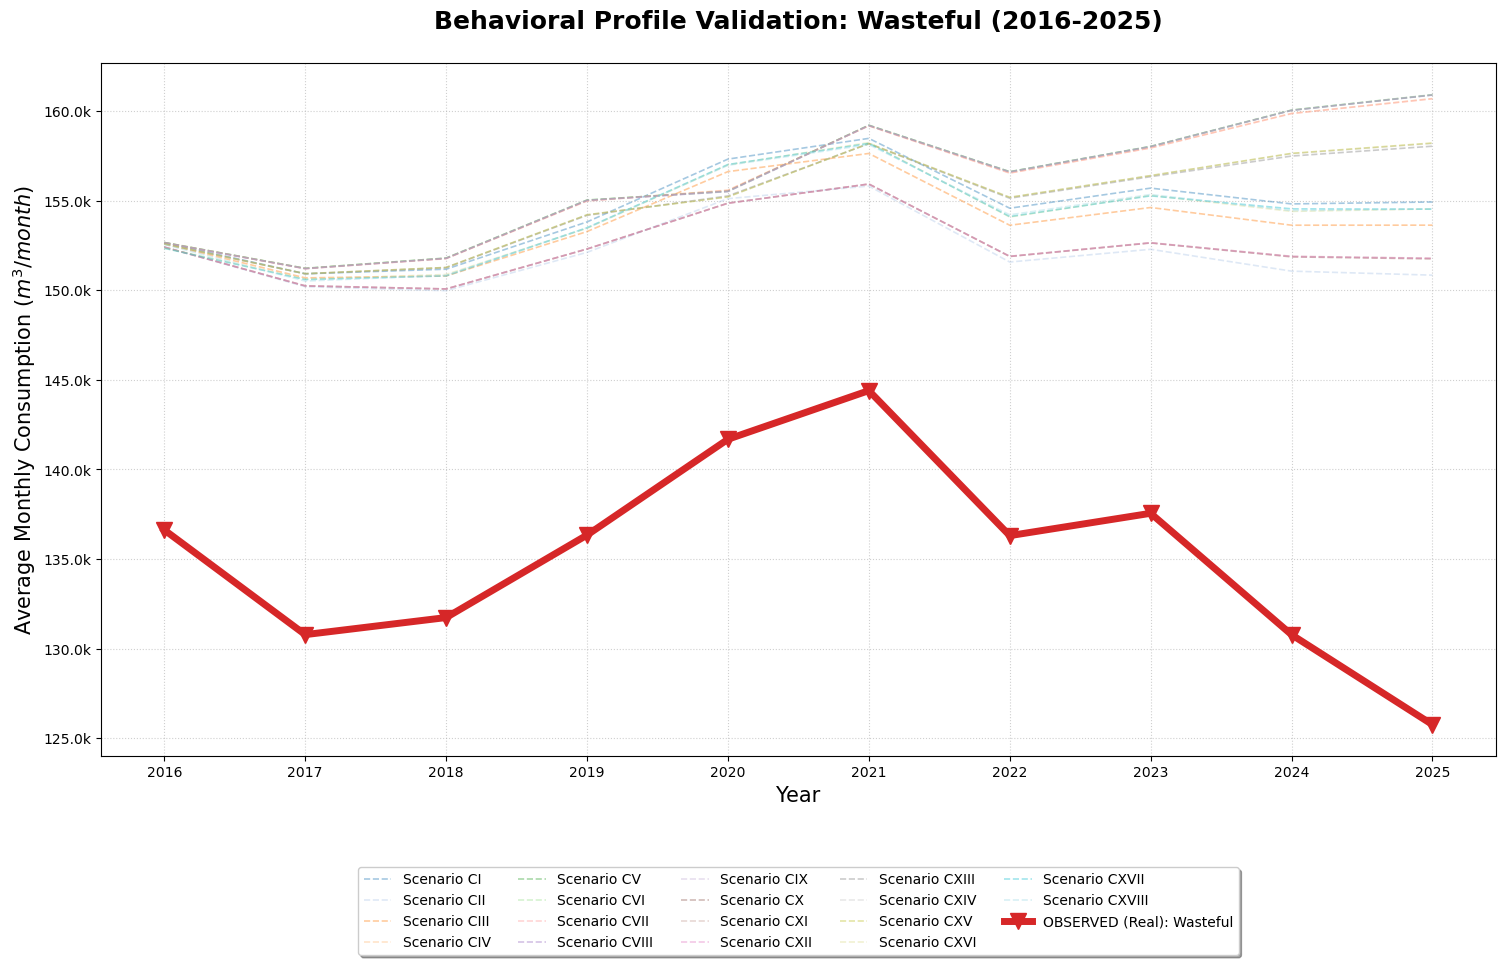

Plotting AMBIENTALISTA...


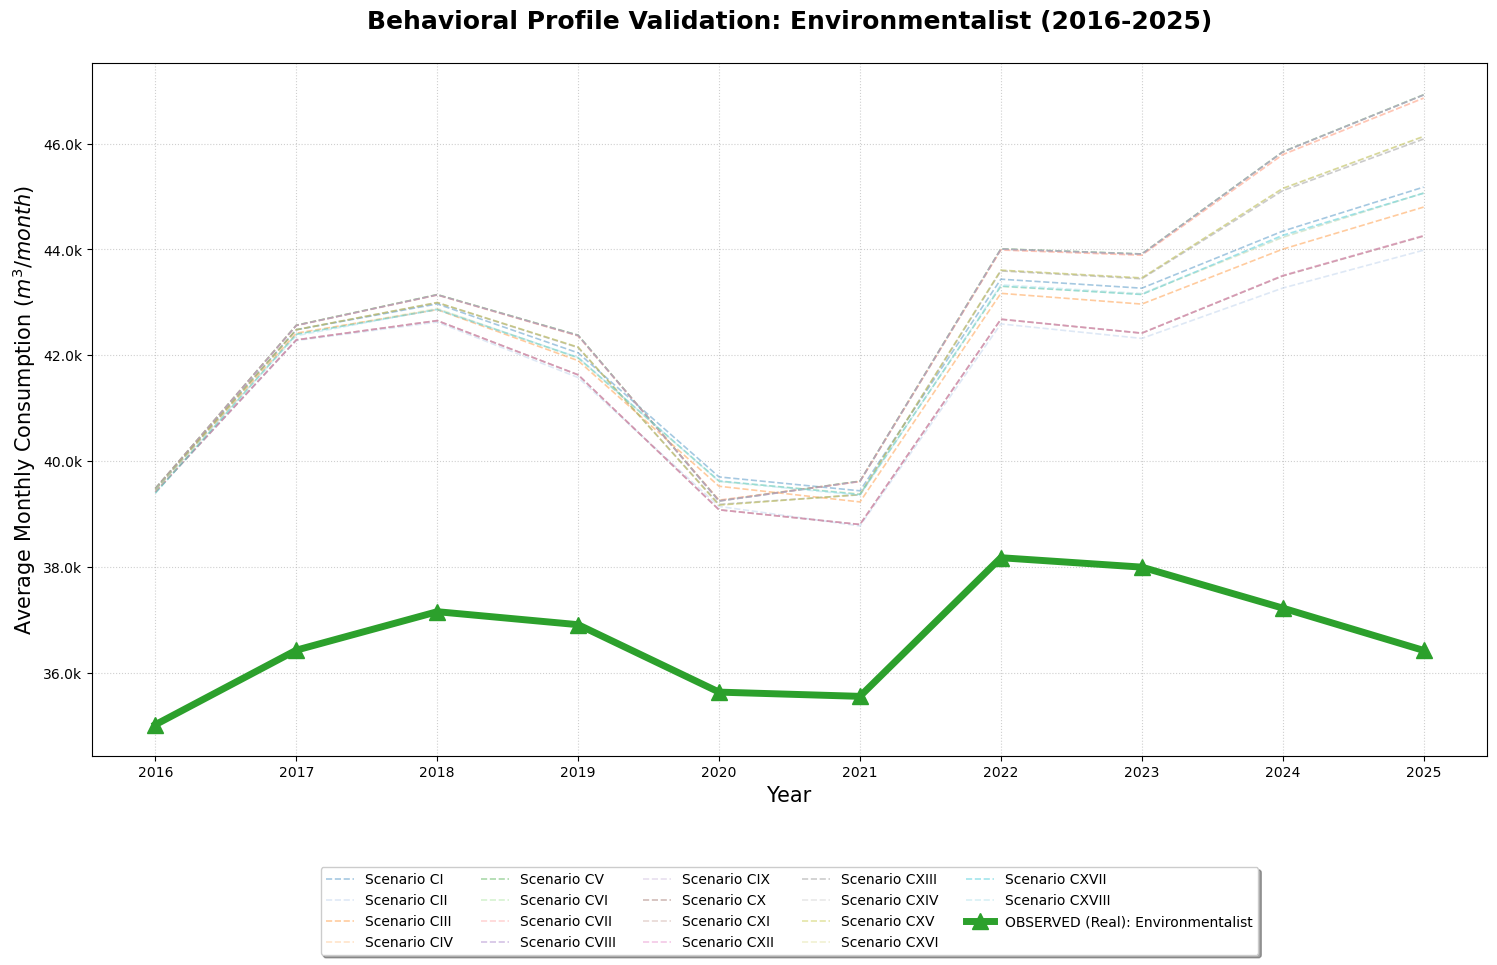

Plotting MODERADO...


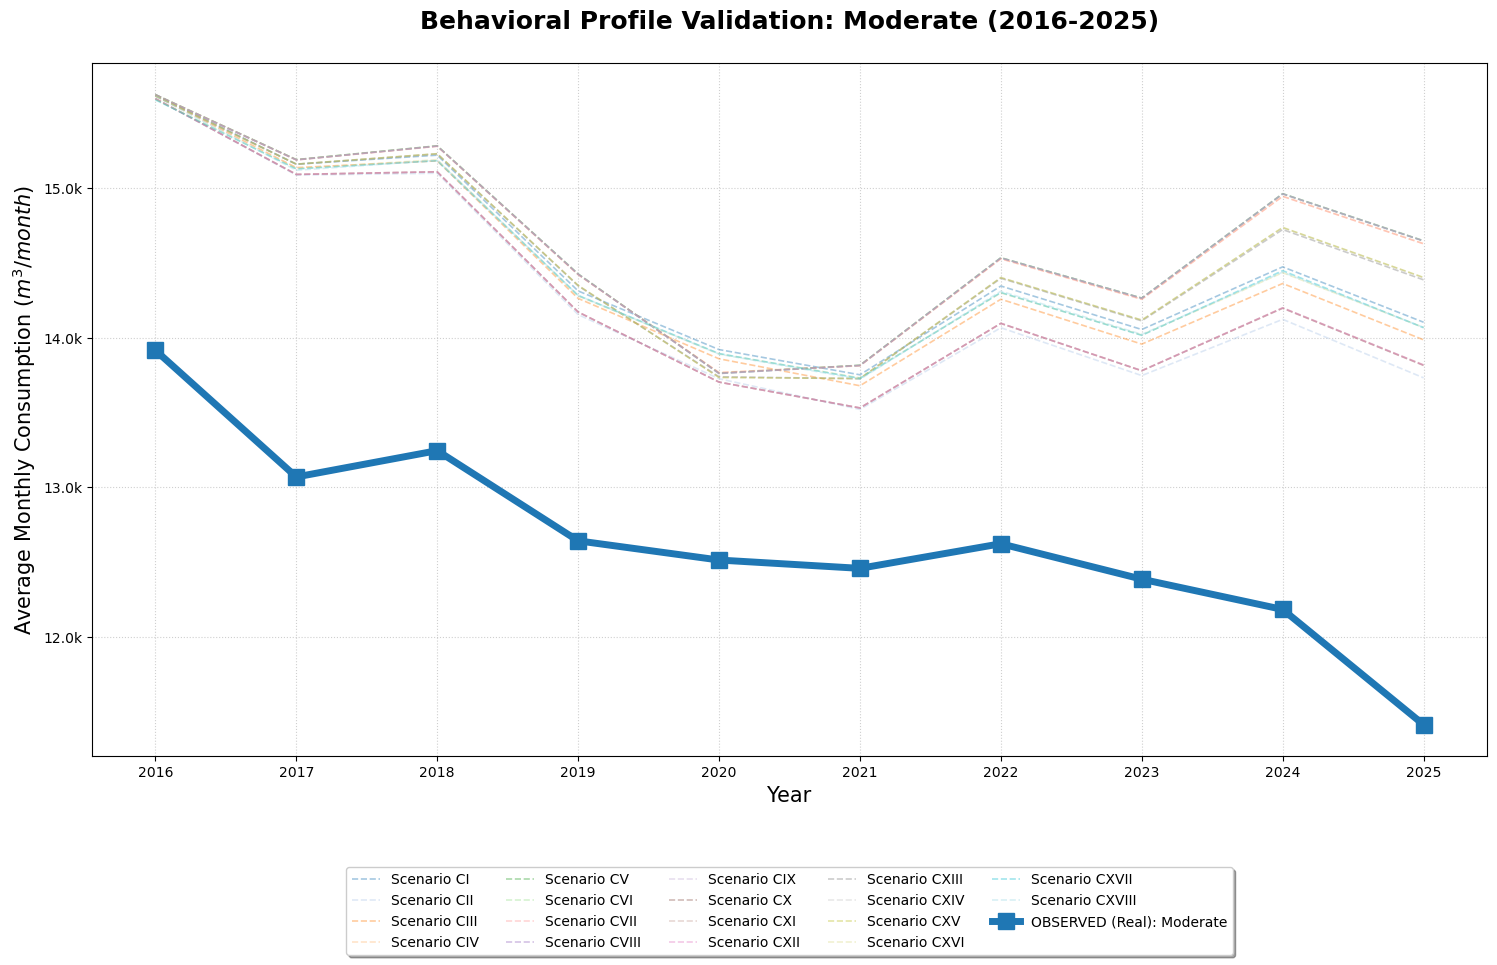

All charts saved in ..\figuras


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
BASELINE_FILE = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv'
HISTORY_120M = 'Tabela_consumo_Itapua_120m.csv'
TOTAL_HISTORY_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def classify_profile(daily_liters):
    if daily_liters < 100.0: return 'AMBIENTALISTA'
    elif daily_liters <= 121.5: return 'MODERADO'
    else: return 'PERDULARIO'

def aggregate_annually_mean(df, date_col, value_cols):
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].mean().reset_index()

def main():
    print("--- Generating Behavioral Validation Charts with Footer Legends ---")

    # ==========================================
    # 2. Data Preparation
    # ==========================================
    
    # A. Real Data
    df_total_ref = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, TOTAL_HISTORY_FILE), sep=';', decimal='.')
    df_total_ref['Date'] = pd.to_datetime(df_total_ref['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    
    df_residents = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, BASELINE_FILE), sep=';')[['SK_MATRICULA', 'NN_MORADORES_ANALISE']]
    df_120m = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, 'dados', HISTORY_120M), sep=';', decimal=',')
    df_120m = df_120m[(df_120m['AM_REFERENCIA'] >= 201601) & (df_120m['AM_REFERENCIA'] <= 202512)]

    # Proportions
    df_dynamic = pd.merge(df_120m, df_residents, on='SK_MATRICULA')
    df_dynamic['L_P_DAY'] = (df_dynamic['HCLQTCON'] * 1000 / df_dynamic['NN_MORADORES_ANALISE']) / 30.5
    df_dynamic['PROFILE'] = df_dynamic['L_P_DAY'].apply(classify_profile)
    monthly_sum = df_dynamic.groupby(['AM_REFERENCIA', 'PROFILE'])['HCLQTCON'].sum().unstack(fill_value=0)
    monthly_prop = monthly_sum.div(monthly_sum.sum(axis=1), axis=0).reset_index()

    # B. Simulation Data
    df_sim = pd.read_csv(os.path.join(INPUT_DIR_RESULTS, SIM_FILE), sep=';', decimal=',')
    df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    df_sim['AM_REFERENCIA'] = (df_sim['Ano'] * 100 + df_sim['Mes']).astype(int)
    sim_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    # ==========================================
    # 3. Plotting Loop
    # ==========================================
    profiles_config = {
        'PERDULARIO': {'color': '#d62728', 'label': 'Wasteful', 'marker': 'v'},
        'AMBIENTALISTA': {'color': '#2ca02c', 'label': 'Environmentalist', 'marker': '^'},
        'MODERADO': {'color': '#1f77b4', 'label': 'Moderate', 'marker': 's'}
    }

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    for p_key, p_info in profiles_config.items():
        print(f"Plotting {p_key}...")
        
        # Data Decomposing
        df_p_real = pd.merge(df_total_ref, monthly_prop[['AM_REFERENCIA', p_key]], on='AM_REFERENCIA')
        df_p_real['P_REAL_CONS'] = df_p_real['real_total_consumption'] * df_p_real[p_key]
        
        df_p_sim = pd.merge(df_sim, monthly_prop[['AM_REFERENCIA', p_key]], on='AM_REFERENCIA')
        for col in sim_cols:
            df_p_sim[col] = df_p_sim[col] * df_p_sim[p_key]

        # Aggregation
        df_p_real_annual = aggregate_annually_mean(df_p_real, 'Date', ['P_REAL_CONS'])
        df_p_sim_annual = aggregate_annually_mean(df_p_sim, 'Date', sim_cols)

        # Plot
        fig, ax = plt.subplots(figsize=(18, 11))
        
        # Scenarios (Now with labels for legend)
        palette = plt.cm.tab20(np.linspace(0, 1, len(sim_cols)))
        for i, col in enumerate(sim_cols):
            scen_name = col.split('_')[0]
            ax.plot(df_p_sim_annual['Year'], df_p_sim_annual[col], color=palette[i], 
                    linestyle='--', alpha=0.4, linewidth=1.2, label=f"Scenario {scen_name}")

        # Real Observed Line
        ax.plot(df_p_real_annual['Year'], df_p_real_annual['P_REAL_CONS'], 
                color=p_info['color'], label=f'OBSERVED (Real): {p_info["label"]}', 
                linewidth=5.0, marker=p_info['marker'], markersize=12, zorder=30)

        # Formatting
        ax.set_title(f'Behavioral Profile Validation: {p_info["label"]} (2016-2025)', fontsize=18, fontweight='bold', pad=25)
        ax.set_ylabel('Average Monthly Consumption ($m^3/month$)', fontsize=15)
        ax.set_xlabel('Year', fontsize=15)
        
        ax.set_xticks(df_p_real_annual['Year'])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.1f}k'))
        plt.grid(True, linestyle=':', alpha=0.6)

        # Legend at the Bottom (Footer)
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                   ncol=5, fontsize=10, frameon=True, shadow=True)

        plt.subplots_adjust(bottom=0.25)
        
        # Save and Show
        output_name = f'figure-validation-profile-{p_key.lower()}.pdf'
        plt.savefig(os.path.join(OUTPUT_DIR, output_name), format='pdf', bbox_inches='tight')
        plt.show()

    print(f"All charts saved in {OUTPUT_DIR}")

if __name__ == "__main__":
    main()